# Barplot of PBMC combined data- irt NK cell types in cNK, iML and unclassified
## Percentage of NK cell types across samples

In [2]:
import scanpy as sc
import anndata as ad
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load all cohorts and include PBMC only

*load malmberg data filtered and subset to PBMC*

In [4]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [6]:
adata.obs

,sample,batch,subset,dataset,source,total_counts,n_genes_by_counts,pct_counts_mt,_scvi_batch,_scvi_labels,...,HALLMARK_GLYCOLYSIS_auc,HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc,subset_source,bright_dim_subset,reference,Malmberg_patient,patient_ID,dataset_v2,patient_ID_v2,classification
AAACCTGAGTGTCCAT_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1345.0,725.0,2.304833,401,0,...,0.041626,0.005439,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,CD56dim
AAACCTGCACATGGGA_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,2108.0,884.0,2.182163,401,0,...,0.033480,0.000000,NKG2A+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,ML1
AAACCTGCACCTCGGA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1821.0,853.0,2.471170,401,0,...,0.054942,0.000000,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,CD56dim
AAACCTGGTTGAGTTC_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,1294.0,753.0,2.086553,401,0,...,0.041032,0.018933,NKG2A+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,ML1
AAACCTGTCACCGTAA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1637.0,831.0,1.710446,401,0,...,0.035483,0.013773,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1,CD56dim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rGBM-04-4_TAAGTCGGTTCTTGCC-1-0-1_abdelfattah_rGBM-04,rGBM-04,rGBM-04,TiCD56bright,abdelfattah,glioblastoma,2693.0,1184.0,3.564798,843,0,...,0.028977,0.000000,TiCD56bright_glioblastoma,CD56bright,tumor,rGBM-04_abdelfattah,rGBM-04_abdelfattah,abdelfattah,rGBM-04_abdelfattah,CD56dim
rGBM-05-2_ATATCCTAGTCATACC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,1946.0,1059.0,1.593011,844,0,...,0.055180,0.026290,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah,CD56dim
rGBM-05-2_CCCTCAACATAGACTC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,2335.0,1371.0,2.655246,844,0,...,0.038762,0.006032,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah,CD56dim
rGBM-05-3_AGGAAATCATTCATCT-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,5610.0,1888.0,8.039216,844,0,...,0.034727,0.000000,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah,CD56dim


In [7]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [8]:
adata.obs["source"].value_counts()

source
lung_normal        23433
PBMC               23120
lung_tumor         17860
glioblastoma        5305
breast_tumor        4941
melanoma            2714
sarcoma             1621
pancreas_tumor      1104
pancreas_normal      655
breast_normal        603
prostate_tumor       530
prostate_normal      265
skin_normal          257
Name: count, dtype: int64

In [9]:
adata_PBMC_Malm= adata[adata.obs['source'] == 'PBMC'].copy()
adata_PBMC_Malm

AnnData object with n_obs × n_vars = 23120 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [10]:
adata_PBMC_Malm.obs["classification"].value_counts()

classification
CD56dim          18912
CD56bright        1280
ML1               1271
ML_transition      851
ML2                503
unclassified       303
Name: count, dtype: int64

*load ding data and subset to PBMC*

In [12]:
adata_ding=sc.read_h5ad('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/nk_ding_eMLclassified_adata_batch_DataSource_Chemistry_classification_SourceType_v2_TcellFiltered.h5ad')

In [13]:
adata_ding

AnnData object with n_obs × n_vars = 11170 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'Source_type_v2'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [14]:
adata_ding.obs

,X,orig.ident,nCount_RNA,nFeature_RNA,nCount_SCT,nFeature_SCT,seurat_clusters,Sample_ATAC,Cancer,Sample_type,...,dataset_name,CD56brightBBCprob,CD56dimBBCprob,eML1BBCprob,eML2BBCprob,predictionsBBC,classification,Source,Source_type,Source_type_v2
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1,BRCA_HT137B1-S1H7_AATTCCTGTAACCCTA-1,HT137B1-XBn1-1,2434,1400,1831,1370,18,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,Query,0.002870,0.868367,0.118725,0.010038,CD56dim,CD56dim,Breast,Breast_Primary tumor,BRCA_PT
BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1,BRCA_HT137B1-S1H7_ACGGTCGAGGATTTGA-1,HT137B1-XBn1-1,1323,1019,1325,1019,31,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,Query,0.000048,0.994730,0.001647,0.003575,CD56dim,CD56dim,Breast,Breast_Primary tumor,BRCA_PT
BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1,BRCA_HT137B1-S1H7_ACGTACAAGGCTCTCG-1,HT137B1-XBn1-1,1394,1021,1394,1021,18,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,Query,0.000142,0.996890,0.001814,0.001155,CD56dim,CD56dim,Breast,Breast_Primary tumor,BRCA_PT
BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1,BRCA_HT137B1-S1H7_CCTAACCCATTCTCCG-1,HT137B1-XBn1-1,1140,865,1172,865,36,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,Query,0.983271,0.010200,0.005565,0.000964,CD56bright,CD56bright,Breast,Breast_Primary tumor,BRCA_PT
BRCA_HT137B1-S1H7_CGTTGGGGTGTCCTAA-1,BRCA_HT137B1-S1H7_CGTTGGGGTGTCCTAA-1,HT137B1-XBn1-1,1550,1110,1539,1110,36,TWCE-HT137B1-XBa1,BRCA,Primary tumor,...,Query,0.380308,0.538672,0.077245,0.003775,CD56dim,CD56dim,Breast,Breast_Primary tumor,BRCA_PT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCTAC-1,PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCT...,ATAC,3925,1913,1956,1423,31,PBMC_pbmc_granulocyte_sorted_3k,PBMC,Normal,...,Query,0.000110,0.997473,0.000662,0.001756,CD56dim,CD56dim,Blood,Blood_Normal,PBMC
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGCAACAAG-1,PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGCAACA...,ATAC,3084,1790,2060,1680,36,PBMC_pbmc_granulocyte_sorted_3k,PBMC,Normal,...,Query,0.996603,0.002751,0.000466,0.000180,CD56bright,CD56bright,Blood,Blood_Normal,PBMC
PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTGAG-1,PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTG...,ATAC,7616,3142,1472,1120,18,PBMC_pbmc_granulocyte_sorted_3k,PBMC,Normal,...,Query,0.269641,0.616249,0.094721,0.019389,CD56dim,CD56dim,Blood,Blood_Normal,PBMC


In [15]:
adata_ding.obs["Data.source"].value_counts()

Data.source
DingLab    10213
10x          957
Name: count, dtype: int64

In [16]:
adata_ding.obs["classification"].value_counts()

classification
CD56dim          8575
CD56bright        930
ML1               803
ML_transition     407
unclassified      397
ML2                58
Name: count, dtype: int64

In [18]:
adata_ding.obs.groupby("Source_type_v2")["Case_ID_RNA"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/3325479453.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_ding.obs.groupby("Source_type_v2")["Case_ID_RNA"].nunique()


Source_type_v2
BRCA_Met          1
BRCA_PT          16
Bone_marrow_N     3
CESC_PT           8
CRC_Met          12
CRC_PT            3
Colorectal_N      1
GBM_PT           13
HNSCC_PT         13
Kidney_N          2
MM_PT            10
OV_Met            2
OV_PT             3
PBMC              4
PDAC_Met          7
PDAC_PT          10
SKCM_Met         14
SKCM_PT           3
Skin_N            1
UCEC_Met          3
UCEC_PT           4
Uterus_N          1
ccRCC_PT         25
Name: Case_ID_RNA, dtype: int64

In [19]:
#renaming columns of ding data to match malmberg adata

In [20]:
adata_ding.obs.rename(columns={
    'Sample_RNA': 'sample',
    'Case_ID_RNA': 'patient_ID_v2',
    'Source_type_v2': 'source',
    'Data.source':"dataset_v2"
}, inplace=True)

In [21]:
adata_ding

AnnData object with n_obs × n_vars = 11170 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'sample', 'patient_ID_v2', 'S.Score', 'G2M.Score', 'Phase', 'dataset_v2', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'source'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [22]:
adata_PBMC_Ding= adata_ding[adata_ding.obs["source"] == 'PBMC'].copy()
adata_PBMC_Ding

AnnData object with n_obs × n_vars = 957 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'sample', 'patient_ID_v2', 'S.Score', 'G2M.Score', 'Phase', 'dataset_v2', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'source'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [23]:
adata_PBMC_Ding.obs['sample'].unique()

['10k_PBMC_3p_nextgem_Chromium_X', 'granulocyte_sorted_10k', 'pbmc_unsorted_10k', 'pbmc_granulocyte_sorted_3k']
Categories (4, object): ['10k_PBMC_3p_nextgem_Chromium_X', 'granulocyte_sorted_10k', 'pbmc_granulocyte_sorted_3k', 'pbmc_unsorted_10k']

In [24]:
# Replace each one individually- as these samples belong to same patient according to information from 10x
adata_PBMC_Ding.obs['patient_ID_v2'] = adata_PBMC_Ding.obs['patient_ID_v2'].replace({
    'pbmc_granulocyte_sorted_10k': '10x_multiome',
    'pbmc_granulocyte_sorted_3k': '10x_multiome',
    'pbmc_unsorted_10k': '10x_multiome'
})

print("Updated patient_ID_v2:")
print(adata_PBMC_Ding.obs['patient_ID_v2'].value_counts())

Updated patient_ID_v2:
patient_ID_v2
10x_multiome                      501
10k_PBMC_3p_nextgem_Chromium_X    456
Name: count, dtype: int64


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/3217483781.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_PBMC_Ding.obs['patient_ID_v2'] = adata_PBMC_Ding.obs['patient_ID_v2'].replace({


In [25]:
adata_PBMC_Ding.obs['sample'] = adata_PBMC_Ding.obs['sample'].replace({
    'granulocyte_sorted_10k': '10x_multiome',
    'pbmc_granulocyte_sorted_3k': '10x_multiome',
    'pbmc_unsorted_10k': '10x_multiome'})

print("Updated sample:")
print(adata_PBMC_Ding.obs['sample'].value_counts())

Updated sample:
sample
10x_multiome                      501
10k_PBMC_3p_nextgem_Chromium_X    456
Name: count, dtype: int64


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/2763493473.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_PBMC_Ding.obs['sample'] = adata_PBMC_Ding.obs['sample'].replace({


In [26]:
adata_PBMC_Ding.obs["classification"].value_counts()

classification
CD56dim         875
CD56bright       65
ML1               7
unclassified      7
ML2               3
Name: count, dtype: int64

In [27]:
X = adata_PBMC_Malm.X
print(X.data[:20])
print("Max value:", X.data.max())

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Max value: 392.0


In [28]:
print(adata_PBMC_Ding.X[adata_PBMC_Ding.X != 0][:20])

[1.5240247 1.027951  1.027951  1.027951  1.5240247 1.027951  1.027951
 1.5240247 1.027951  1.027951  1.027951  1.027951  1.5240247 1.027951
 1.027951  2.1018546 1.027951  1.5240247 1.8541076 1.5240247]


In [29]:
print(adata_PBMC_Ding.layers["counts"][adata_PBMC_Ding.layers["counts"] != 0][:20])

[2. 1. 1. 1. 2. 1. 1. 2. 1. 1. 1. 1. 2. 1. 1. 4. 1. 2. 3. 2.]


*load CIML data*

In [30]:
adata_PCIML_TCIML = ad.read_h5ad('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Science_Immuno_TCIML_PCIML/combined_classified_PCIML_TCIML_SI_adata_PBMC_donors_DayZero.h5ad')

In [31]:
adata_PCIML_TCIML

AnnData object with n_obs × n_vars = 42232 × 33672
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'species', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1', 'seurat_clusters', 'unfilt_clusters', 'RNA_snn_res.0.8', 'RNA_snn_res.0.4', 'RNA_snn_res.0.6', 'Renamed', 'predicted.spca.NK_annot.ref.score', 'predicted.spca.NK_annot.ref', 'predicted.spca.main.NK.ref.score', 'predicted.spca.main.NK.ref', 'predicted.spca.major.ref.score', 'predicted.spca.major.ref', 'predicted.spca.NK_annot.score', 'predicted.spca.NK_annot', 'predicted.spca.main.NK.score', 'predicted.spca.main.NK', 'predicted.spca.major.score', 'predicted.spca.major', 'predicted.spca.harmony.score', 'predicted.spca.harmony', 'predicted.spca.main.score', 'predicted.spca.main', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob'

In [32]:
adata_PCIML_TCIML.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,percent.mt,species,S.Score,G2M.Score,Phase,...,ML_3_matchprob,ML_4_matchprob,LD_CD56dim2_matchprob,ML_ModuleScoreMax,CD56dim_ModuleScoreMax,reclustered,RNA.weight,RNA_snn_res.0.5,NK_res_0.5,NK_res_0.4
PCIML2_Donor_AAACCTGAGCAAATCA-1,PCIML2_Donor,2557,1401,2052.0,28.0,7.743449,human,-0.038079,-0.105170,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCIML2_Donor_AAACCTGAGCAGGCTA-1,PCIML2_Donor,515,390,513.0,27.0,4.271845,human,-0.026367,-0.003975,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCIML2_Donor_AAACCTGAGCGTCTAT-1,PCIML2_Donor,799,585,769.0,28.0,0.750939,human,-0.034900,0.123653,G2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCIML2_Donor_AAACCTGAGCTAGGCA-1,PCIML2_Donor,1566,854,3446.0,28.0,5.427842,human,0.008850,0.026766,G2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCIML2_Donor_AAACCTGAGGCCATAG-1,PCIML2_Donor,1030,688,327.0,28.0,3.106796,human,0.010925,-0.029864,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCIML7_Donor_CGACTTCGTAGAGCTG-1,TCIML7_Donor,5376,2122,0.0,0.0,5.543155,NaN,-0.038829,-0.088619,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCIML7_Donor_CTCGGAGAGCGAAGGG-1,TCIML7_Donor,3469,1545,0.0,0.0,5.073508,NaN,-0.015941,-0.131759,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCIML7_Donor_GGAACTTCACGGTAGA-1,TCIML7_Donor,4477,1775,0.0,0.0,5.673442,NaN,-0.032451,-0.055365,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCIML7_Donor_GGTGTTACAAGTCTGT-1,TCIML7_Donor,3574,1625,0.0,0.0,5.008394,NaN,-0.058602,-0.039636,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
adata_PCIML_TCIML.obs['dataset'].unique()

['PCIML2', 'PCIML7', 'PCIML8', 'TCIML2', 'TCIML3', 'TCIML7']
Categories (6, object): ['PCIML2', 'PCIML7', 'PCIML8', 'TCIML2', 'TCIML3', 'TCIML7']

In [34]:
# Add sample and patient columns (same as dataset)
adata_PCIML_TCIML.obs['sample'] = adata_PCIML_TCIML.obs['dataset']
adata_PCIML_TCIML.obs['patient_ID_v2'] = adata_PCIML_TCIML.obs['dataset']

# Verify
print(adata_PCIML_TCIML.obs[['dataset', 'sample', 'patient_ID_v2']].head())

                                dataset  sample patient_ID_v2
PCIML2_Donor_AAACCTGAGCAAATCA-1  PCIML2  PCIML2        PCIML2
PCIML2_Donor_AAACCTGAGCAGGCTA-1  PCIML2  PCIML2        PCIML2
PCIML2_Donor_AAACCTGAGCGTCTAT-1  PCIML2  PCIML2        PCIML2
PCIML2_Donor_AAACCTGAGCTAGGCA-1  PCIML2  PCIML2        PCIML2
PCIML2_Donor_AAACCTGAGGCCATAG-1  PCIML2  PCIML2        PCIML2


In [35]:
adata_PCIML_TCIML.obs['source'] = 'PBMC'

In [36]:
adata_PCIML_TCIML.obs['source'].unique()

array(['PBMC'], dtype=object)

### Combine Malm, Ding and CIML data

In [37]:
adata_PBMC_Ding.X = adata_PBMC_Ding.layers["counts"].copy()

print(f"adata_PCIML_TCIML: {adata_PCIML_TCIML.n_obs:,} cells × {adata_PCIML_TCIML.n_vars:,} genes")
print(f"adata_PBMC_Malm: {adata_PBMC_Malm.n_obs:,} cells × {adata_PBMC_Malm.n_vars:,} genes")
print(f"adata_PBMC_Ding: {adata_PBMC_Ding.n_obs:,} cells × {adata_PBMC_Ding.n_vars:,} genes")


# Find shared genes
common_genes = (adata_PCIML_TCIML.var_names
                .intersection(adata_PBMC_Malm.var_names)
                .intersection(adata_PBMC_Ding.var_names))

# Subset all three to common genes
adata_PCIML_TCIML = adata_PCIML_TCIML[:, common_genes].copy()
adata_PBMC_Malm = adata_PBMC_Malm[:, common_genes].copy()
adata_PBMC_Ding = adata_PBMC_Ding[:, common_genes].copy()

# Now safely concatenate 
adata_combined_PBMC = ad.concat(
    [adata_PCIML_TCIML, adata_PBMC_Malm, adata_PBMC_Ding],
    join="outer",
    label="data_source_type",
    keys=["SI_PCIML_TCIML", "PBMC_Malm", "PBMC_Ding"]
)


adata_PCIML_TCIML: 42,232 cells × 33,672 genes
adata_PBMC_Malm: 23,120 cells × 14,337 genes
adata_PBMC_Ding: 957 cells × 36,601 genes


/Users/vedanagapriyavangala/Library/Python/3.9/lib/python/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [39]:
adata_combined_PBMC.obs


,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,percent.mt,species,S.Score,G2M.Score,Phase,...,cell_type_v8.5_multi,integrated_snn_res.2.5,cell_type_v8.6_rna,cell_type_v8.7_rna,Sample.source,Tissue.normal,Data.source_Chemistry,Source,Source_type,data_source_type
PCIML2_Donor_AAACCTGAGCAAATCA-1,PCIML2_Donor,2557.0,1401.0,2052.0,28.0,7.743449,human,-0.038079,-0.105170,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGCAGGCTA-1,PCIML2_Donor,515.0,390.0,513.0,27.0,4.271845,human,-0.026367,-0.003975,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGCGTCTAT-1,PCIML2_Donor,799.0,585.0,769.0,28.0,0.750939,human,-0.034900,0.123653,G2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGCTAGGCA-1,PCIML2_Donor,1566.0,854.0,3446.0,28.0,5.427842,human,0.008850,0.026766,G2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGGCCATAG-1,PCIML2_Donor,1030.0,688.0,327.0,28.0,3.106796,human,0.010925,-0.029864,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCTAC-1,ATAC,3925.0,1913.0,NaN,NaN,NaN,NaN,-0.026590,-0.006806,G1,...,CD8 CTL ZNF683,31.0,NK CD56dim,NK CD56dim,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGCAACAAG-1,ATAC,3084.0,1790.0,NaN,NaN,NaN,NaN,-0.014735,-0.022775,G1,...,NK CD56bright KLRC1,36.0,NK CD56bright KLRC1,NK CD56bright KLRC1,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding
PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTGAG-1,ATAC,7616.0,3142.0,NaN,NaN,NaN,NaN,0.011213,0.049290,G2M,...,NK CD56dim,18.0,NK CD56dim,NK CD56dim,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding
PBMC_pbmc_granulocyte_sorted_3k_TTTGTGGCATTGCGAC-1,ATAC,4772.0,2330.0,NaN,NaN,NaN,NaN,-0.025435,-0.001362,G1,...,NK CD56dim,18.0,NK CD56dim,NK CD56dim,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding


In [41]:
adata_combined_PBMC

AnnData object with n_obs × n_vars = 66309 × 14337
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'species', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1', 'seurat_clusters', 'unfilt_clusters', 'RNA_snn_res.0.8', 'RNA_snn_res.0.4', 'RNA_snn_res.0.6', 'Renamed', 'predicted.spca.NK_annot.ref.score', 'predicted.spca.NK_annot.ref', 'predicted.spca.main.NK.ref.score', 'predicted.spca.main.NK.ref', 'predicted.spca.major.ref.score', 'predicted.spca.major.ref', 'predicted.spca.NK_annot.score', 'predicted.spca.NK_annot', 'predicted.spca.main.NK.score', 'predicted.spca.main.NK', 'predicted.spca.major.score', 'predicted.spca.major', 'predicted.spca.harmony.score', 'predicted.spca.harmony', 'predicted.spca.main.score', 'predicted.spca.main', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob'

In [42]:
adata_combined_PBMC.obs["classification"].value_counts()

classification
CD56dim          54323
CD56bright        6775
ML1               2301
ML_transition     1221
unclassified      1015
ML2                674
Name: count, dtype: int64

In [43]:
adata_combined_PBMC.obs["patient_ID_v2"].nunique()

20

In [55]:
plt.rcParams['figure.dpi'] = 600

### Barplot of combined PBMC data

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/3179861837.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs['classification_stacked'] = obs['classification'].replace({
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/3179861837.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stacked = obs.groupby(['source', 'sample', 'classification_stacked']).size().unstack(fill_value=0)
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/3179861837.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to

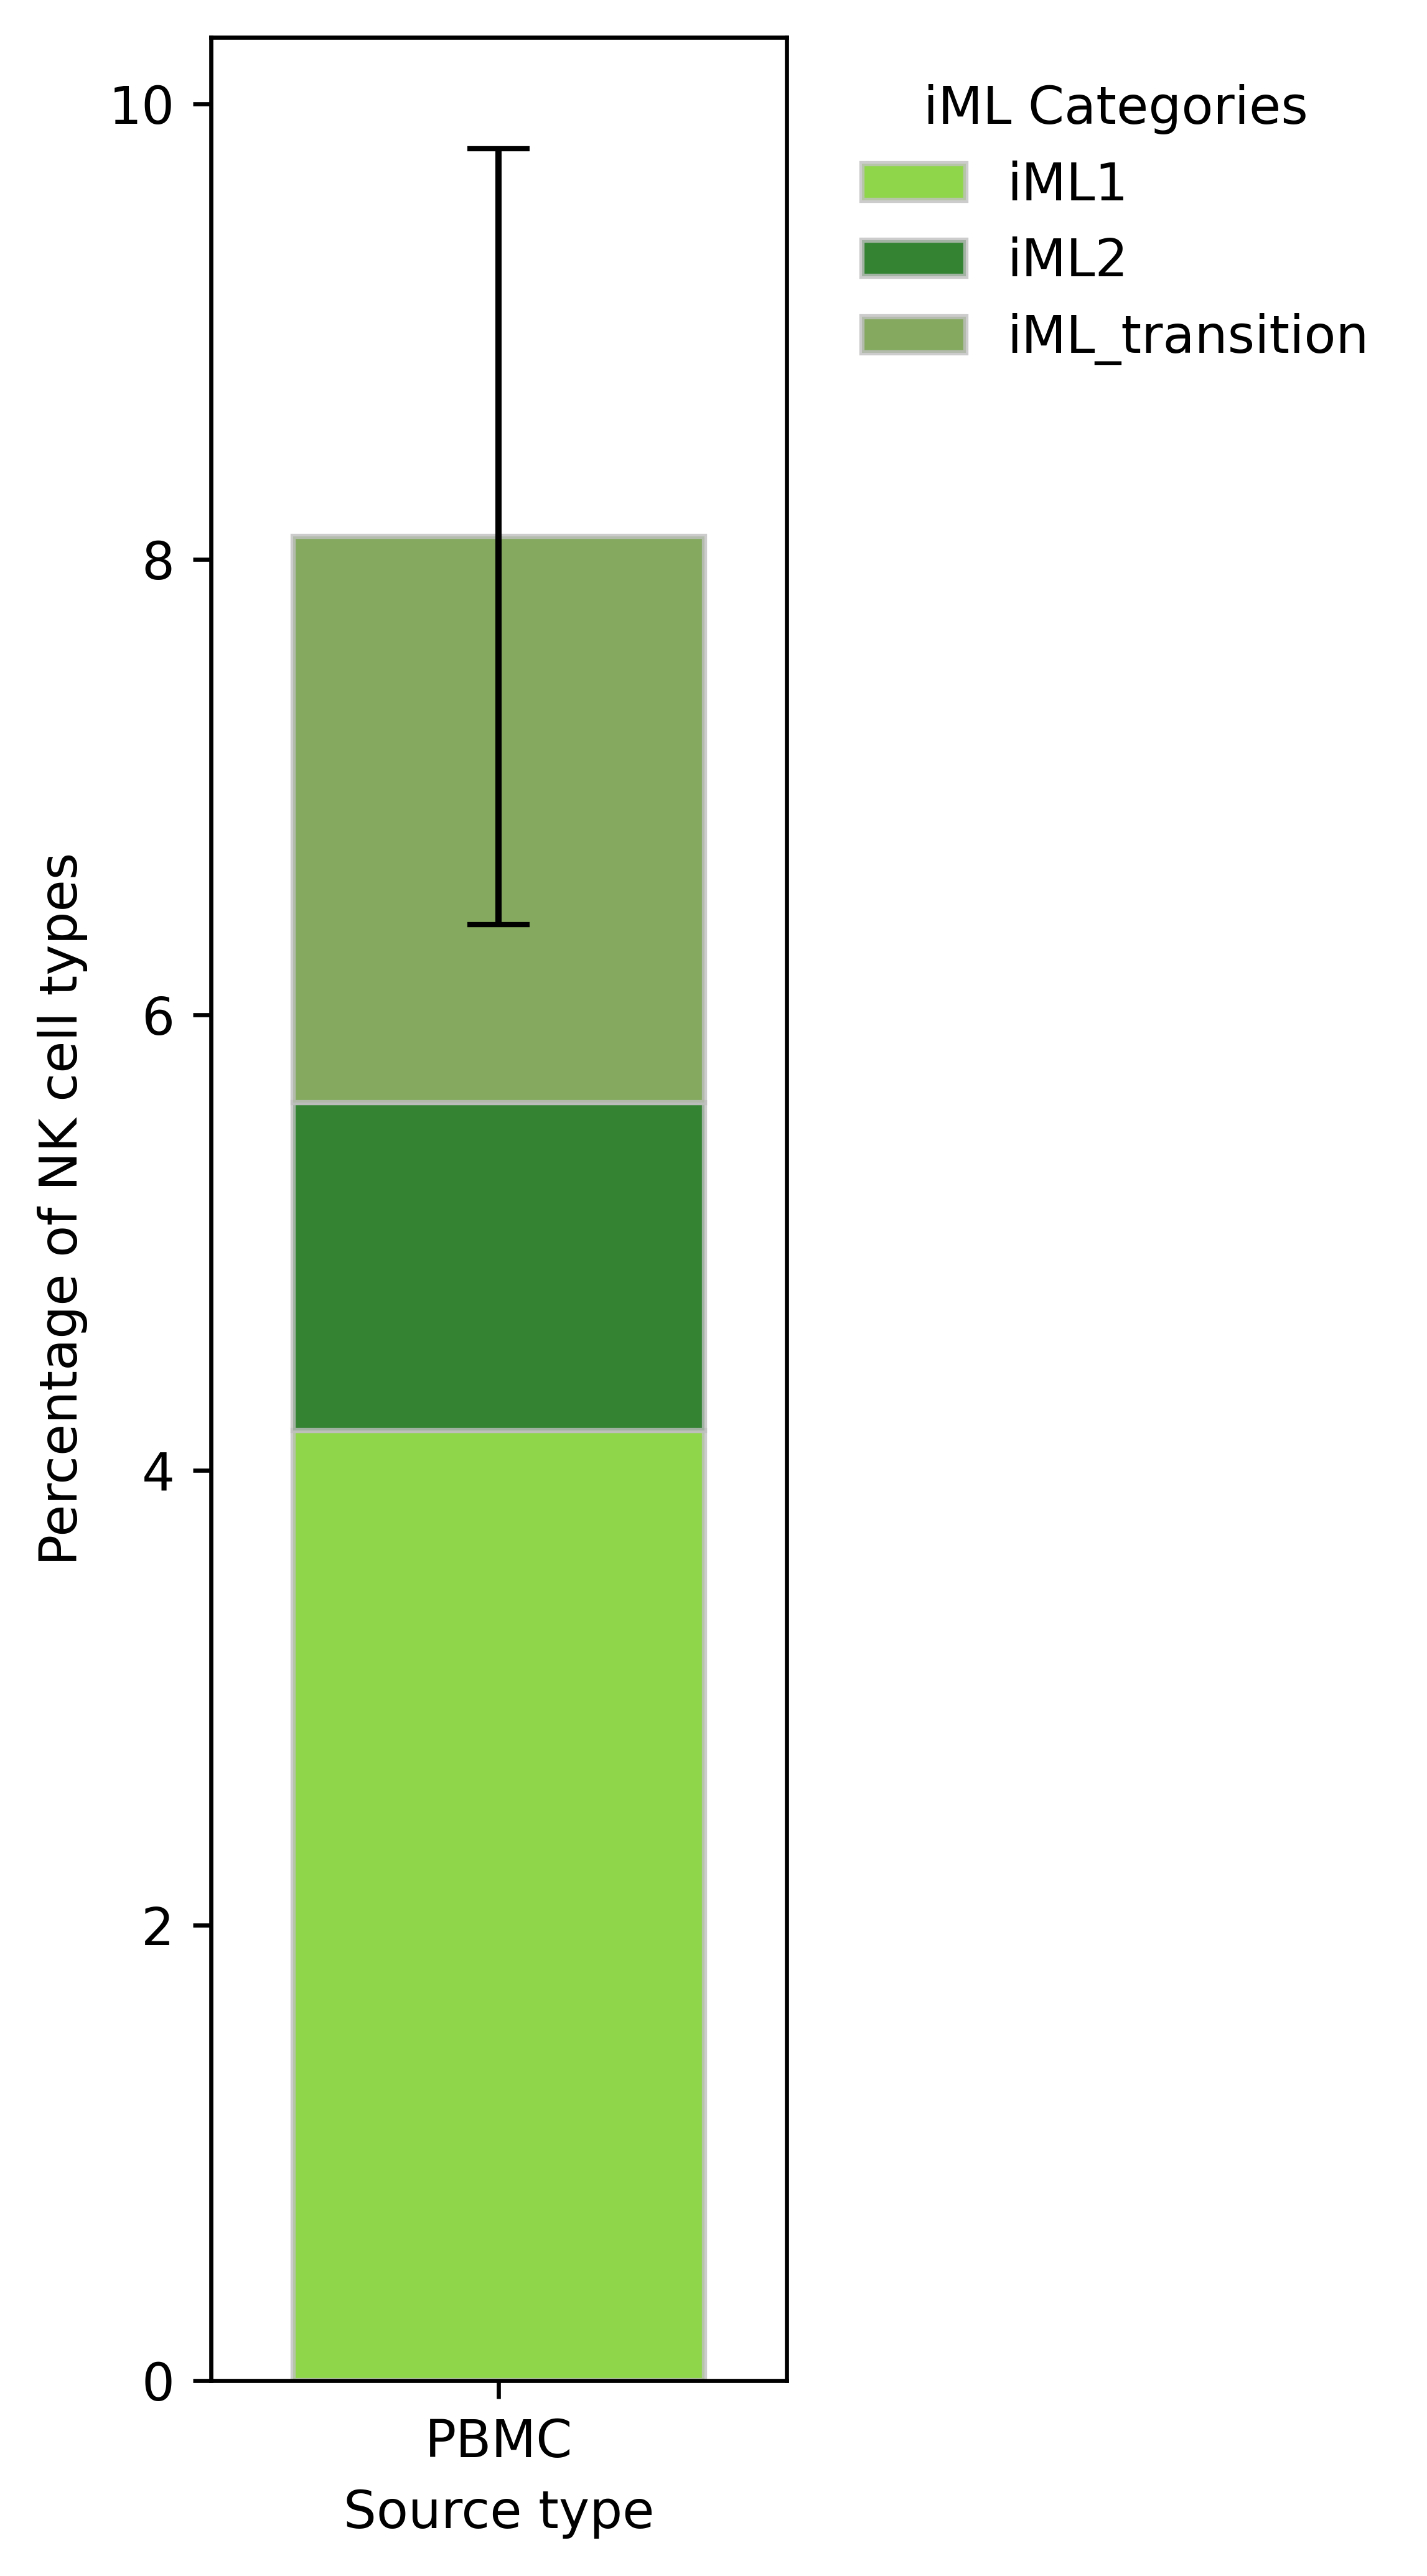

In [56]:
# Define Sources

# Only PBMC
ordered_sources = ['PBMC']

# Prepare Data for Stacked Bar Breakdown 

# Copy and filter obs from adata
obs = adata_combined_PBMC.obs.copy()
obs = obs[obs['source'].isin(ordered_sources)].copy()
obs['source'] = pd.Categorical(obs['source'], categories=ordered_sources, ordered=True)

# Rename ML → iML in stacked categories
obs['classification_stacked'] = obs['classification'].replace({
    'ML1': 'iML1',
    'ML2': 'iML2',
    'ML_transition': 'iML_transition'
})

# Calculate percentages per sample
grouped_stacked = obs.groupby(['source', 'sample', 'classification_stacked']).size().unstack(fill_value=0)
percentages_stacked = grouped_stacked.div(grouped_stacked.sum(axis=1), axis=0) * 100

# New iML categories
ml_categories = ['iML1', 'iML2', 'iML_transition']
mean_ml = percentages_stacked.groupby('source')[ml_categories].mean().loc[ordered_sources]

# Compute SEM for Total iML_combined 

obs_sem = adata_combined_PBMC.obs.copy()
obs_sem = obs_sem[obs_sem['source'].isin(ordered_sources)].copy()
obs_sem['source'] = pd.Categorical(obs_sem['source'], categories=ordered_sources, ordered=True)

# Rename ML → iML
obs_sem['classification'] = obs_sem['classification'].replace({
    'ML1': 'iML_combined',
    'ML2': 'iML_combined',
    'ML_transition': 'iML_combined'
})

grouped_sem = obs_sem.groupby(['source', 'sample', 'classification']).size().unstack(fill_value=0)
percentages_sem = grouped_sem.div(grouped_sem.sum(axis=1), axis=0) * 100

mean_ml_combined = percentages_sem.groupby('source')['iML_combined'].mean().loc[ordered_sources]
sem_ml_combined = percentages_sem.groupby('source')['iML_combined'].sem().loc[ordered_sources]

# Plot
plt.figure(figsize=(4,7))

x = np.arange(len(mean_ml.index)) * 0.30
width = 0.14

# Updated colors dictionary
colors = {
    'iML1': '#74cc1d',
    'iML2': 'darkgreen',
    'iML_transition': '#659437'
}

bottom = np.zeros(len(mean_ml.index))

# Stacked bars
for category in ml_categories:
    plt.bar(
        x,
        mean_ml[category],
        width=width,
        label=category,  # already clean: iML1, iML2 …
        color=colors[category],
        alpha=0.8,
        bottom=bottom,
        edgecolor='silver'
    )
    bottom += mean_ml[category]

# SEM on top
plt.errorbar(
    x,
    bottom,
    yerr=sem_ml_combined,
    fmt='none',
    color='black',
    capsize=6,
    elinewidth=1.2
)

# Formatting
plt.xticks(x, mean_ml.index)
plt.ylabel("Percentage of NK cell types")
plt.xlabel("Source type")
plt.legend(title="iML Categories", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(x=0.20)
plt.tight_layout()
plt.show()


### Saving the combined PBMC data

In [57]:
#adata_combined_PBMC.write('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/PBMC_combined_Malm_ding_Tcell_filtered/PBMC_combined_malm_ding_Tcellfitered_SI_pciml_tciml_Donor.h5ad')

In [58]:
#adata_combined_PBMC.obs.to_csv('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/PBMC_combined_Malm_ding_Tcell_filtered/PBMC_combined_malm_ding_Tcellfitered_SI_pciml_tciml_Donor.csv')

In [ ]:
# copying metadata to df dataframe

In [60]:
df = adata_combined_PBMC.obs.copy()
print(df["classification"].unique())

['CD56dim', 'ML_transition', 'ML1', 'CD56bright', 'unclassified', 'ML2']
Categories (6, object): ['CD56bright', 'CD56dim', 'ML1', 'ML2', 'ML_transition', 'unclassified']


In [61]:
df

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,percent.mt,species,S.Score,G2M.Score,Phase,...,cell_type_v8.5_multi,integrated_snn_res.2.5,cell_type_v8.6_rna,cell_type_v8.7_rna,Sample.source,Tissue.normal,Data.source_Chemistry,Source,Source_type,data_source_type
PCIML2_Donor_AAACCTGAGCAAATCA-1,PCIML2_Donor,2557.0,1401.0,2052.0,28.0,7.743449,human,-0.038079,-0.105170,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGCAGGCTA-1,PCIML2_Donor,515.0,390.0,513.0,27.0,4.271845,human,-0.026367,-0.003975,G1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGCGTCTAT-1,PCIML2_Donor,799.0,585.0,769.0,28.0,0.750939,human,-0.034900,0.123653,G2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGCTAGGCA-1,PCIML2_Donor,1566.0,854.0,3446.0,28.0,5.427842,human,0.008850,0.026766,G2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
PCIML2_Donor_AAACCTGAGGCCATAG-1,PCIML2_Donor,1030.0,688.0,327.0,28.0,3.106796,human,0.010925,-0.029864,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI_PCIML_TCIML
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCTAC-1,ATAC,3925.0,1913.0,NaN,NaN,NaN,NaN,-0.026590,-0.006806,G1,...,CD8 CTL ZNF683,31.0,NK CD56dim,NK CD56dim,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding
PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGCAACAAG-1,ATAC,3084.0,1790.0,NaN,NaN,NaN,NaN,-0.014735,-0.022775,G1,...,NK CD56bright KLRC1,36.0,NK CD56bright KLRC1,NK CD56bright KLRC1,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding
PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTGAG-1,ATAC,7616.0,3142.0,NaN,NaN,NaN,NaN,0.011213,0.049290,G2M,...,NK CD56dim,18.0,NK CD56dim,NK CD56dim,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding
PBMC_pbmc_granulocyte_sorted_3k_TTTGTGGCATTGCGAC-1,ATAC,4772.0,2330.0,NaN,NaN,NaN,NaN,-0.025435,-0.001362,G1,...,NK CD56dim,18.0,NK CD56dim,NK CD56dim,Healthy donor,Blood,10x_Multiome,Blood,Blood_Normal,PBMC_Ding


In [62]:
percentages = df['classification'].value_counts(normalize=True) * 100
print(percentages)

classification
CD56dim          81.924022
CD56bright       10.217316
ML1               3.470117
ML_transition     1.841379
unclassified      1.530712
ML2               1.016453
Name: proportion, dtype: float64


In [75]:
df["sample"].nunique()

20

In [ ]:
# renaming or combining ML1, ML2 and ML transition to iML

In [76]:

df['classification_v2'] = df['classification'].replace({'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML', 'unclassified':'unclassified'})



/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/448799964.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['classification_v2'] = df['classification'].replace({'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML', 'unclassified':'unclassified'})


In [78]:
plt.rcParams['figure.dpi'] = 600

### Percentage of NK cell types across samples

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/3474924078.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_counts = df.groupby(['sample', 'classification_v2']).size().unstack(fill_value=0)


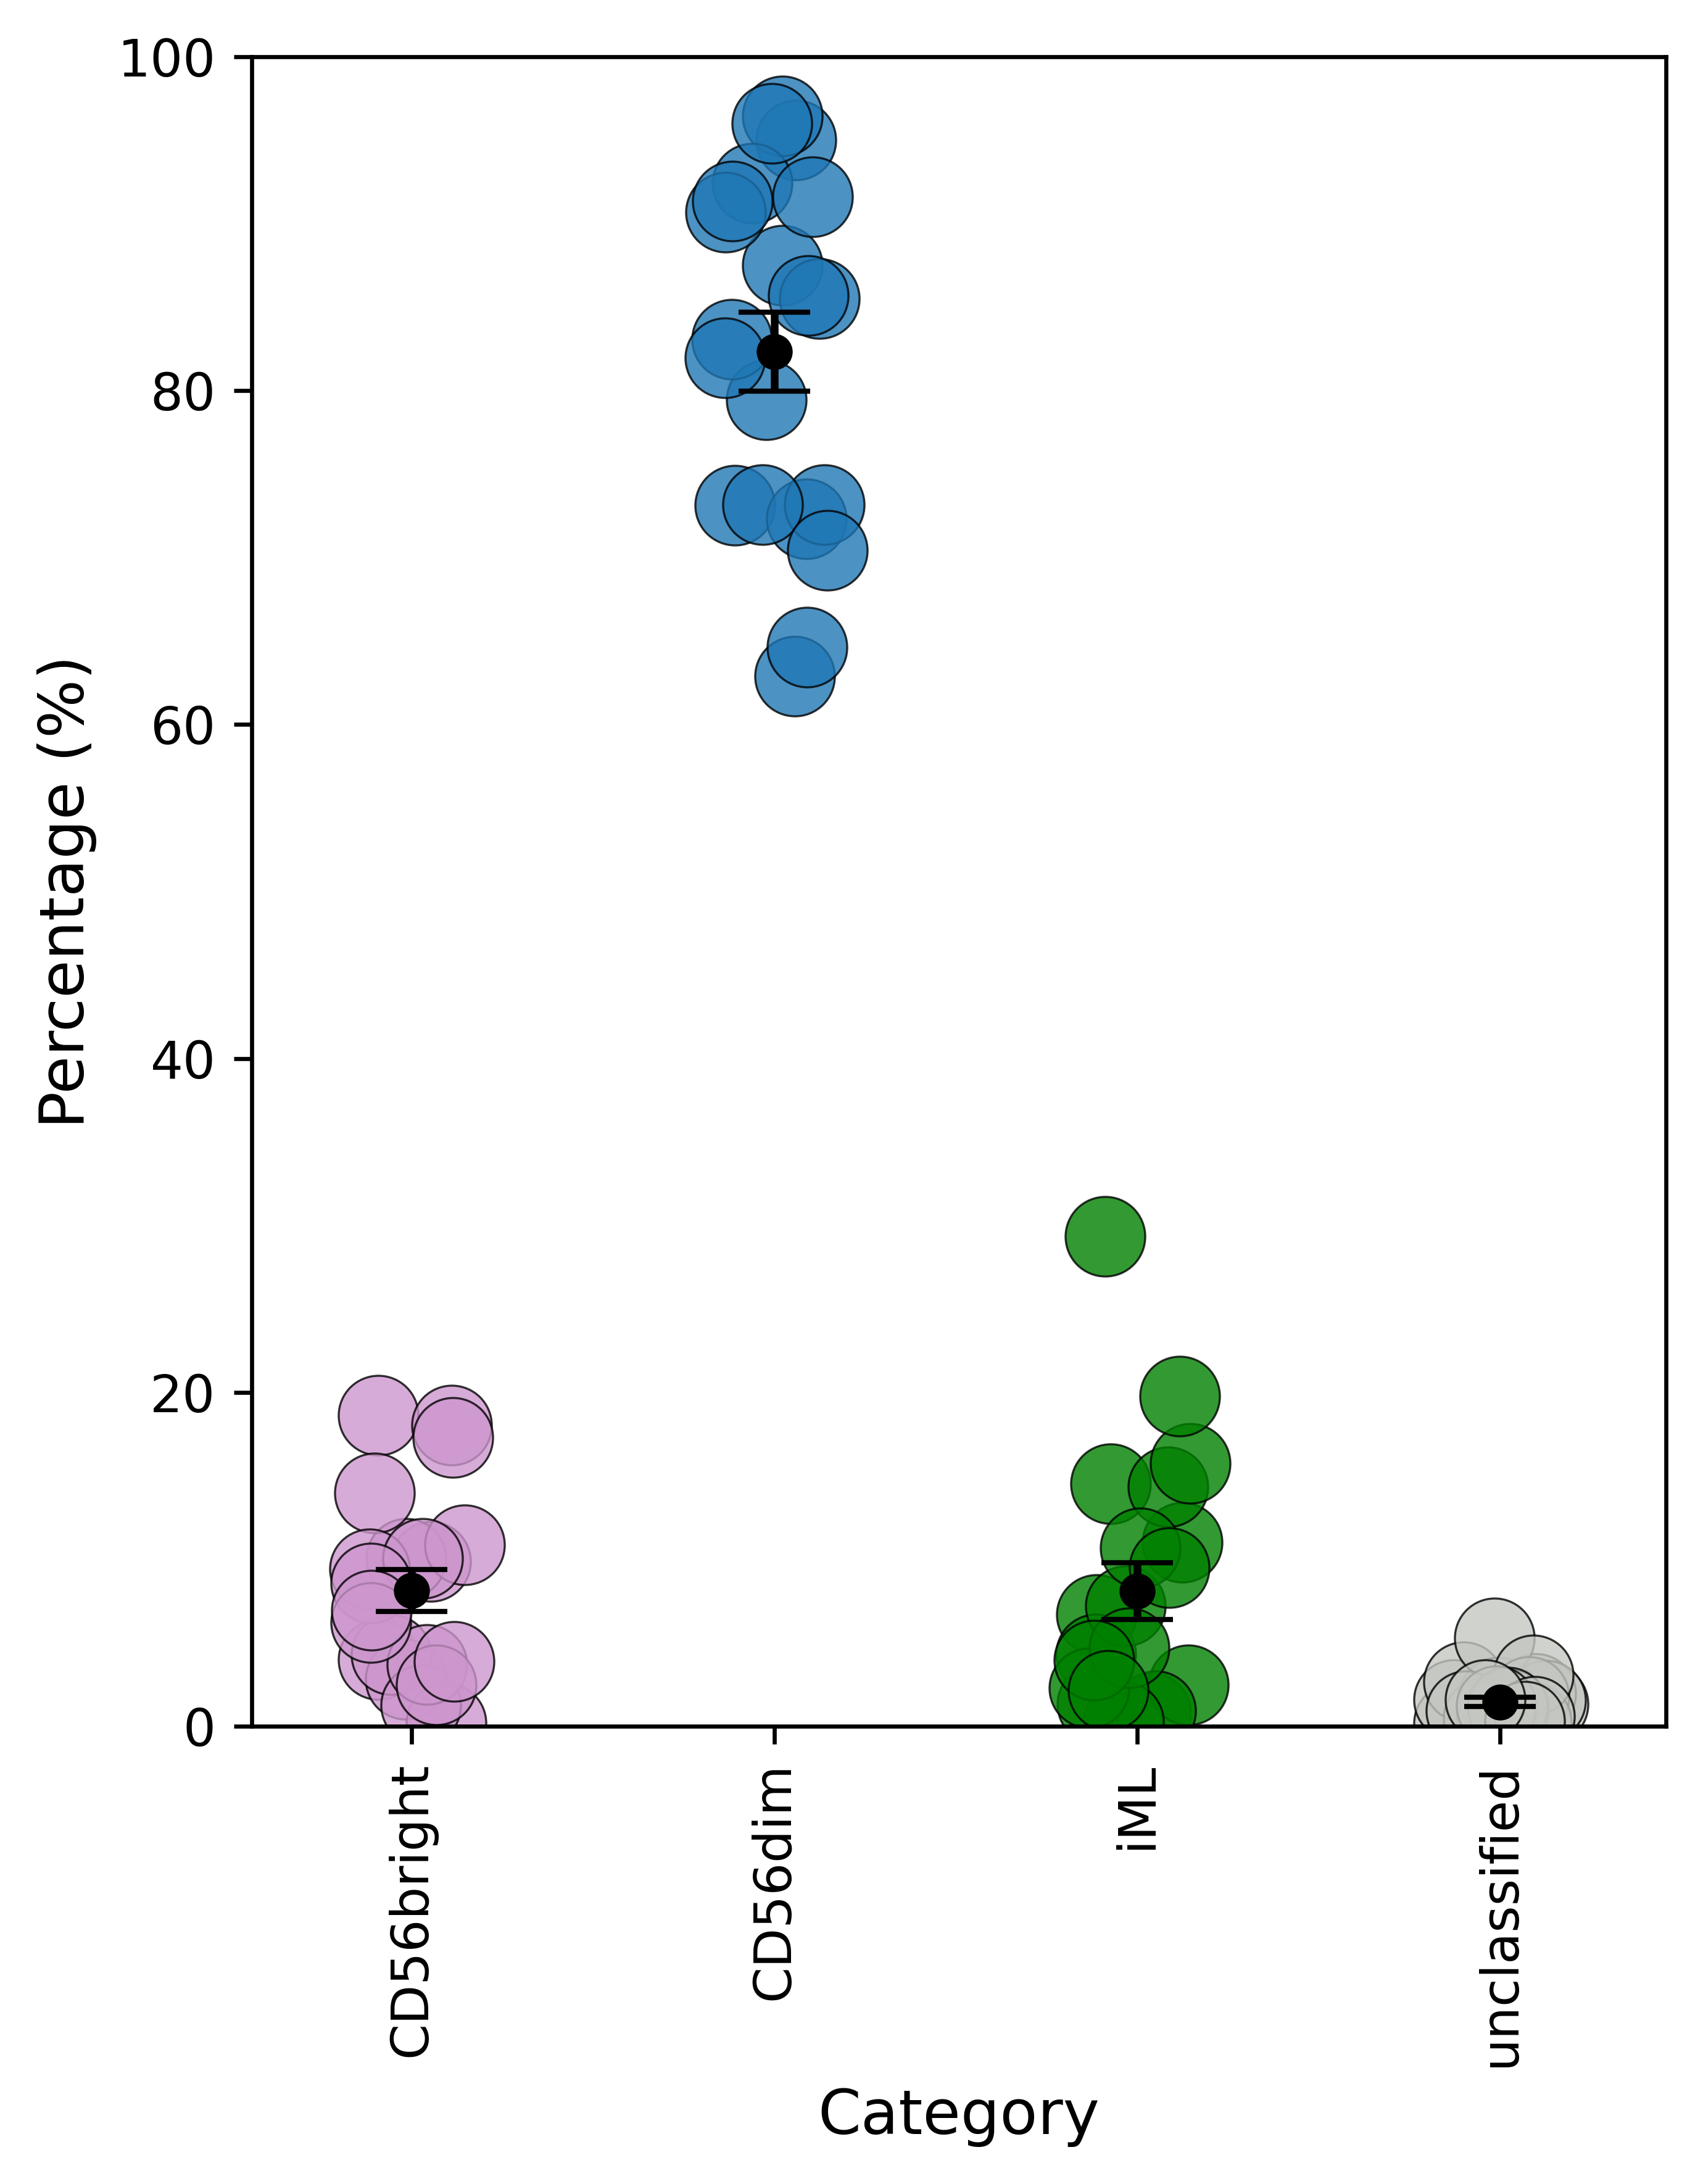

In [79]:
sample_counts = df.groupby(['sample', 'classification_v2']).size().unstack(fill_value=0)
sample_percent = sample_counts.div(sample_counts.sum(axis=1), axis=0) * 100
mean_percent = sample_percent.mean()
sem_percent = sample_percent.sem()  # compute SEM

# --- Custom colors ---
colors = ["#CD96CD", '#1f77b4', 'green', '#c4c7c1']

plt.figure(figsize=(4.7,6))

# Jittered scatter for each sample (individual data points)
for i, cls in enumerate(sample_percent.columns):
    y = sample_percent[cls].values
    x = np.full_like(y, i, dtype=float)
    jitter = (np.random.rand(len(y)) - 0.5) * 0.3  # horizontal jitter
    plt.scatter(
        x + jitter,
        y,
        color=colors[i % len(colors)], 
        alpha=0.8,
        s=240,
        edgecolor='k',
        linewidth=0.4,
        zorder=2
    )

# Overlay mean ± SEM
plt.errorbar(
    range(len(mean_percent)),  # x positions
    mean_percent,              # y = mean
    yerr=sem_percent,          # error bars = SEM
    fmt='o',                   # marker
    color='black',             # mean color
    markersize=6,
    capsize=7,
    elinewidth=1.5,
    zorder=3)

#plt.title('Percentage of Each Category Across Samples with mean ± sem ', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(range(len(mean_percent)), mean_percent.index, rotation=90)
plt.ylim(0, 100)
plt.margins(x=0.10)
#plt.axhline(10, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


In [80]:
sample_counts = df.groupby(['sample', 'classification_v2']).size().unstack(fill_value=0)
sample_percent = sample_counts.div(sample_counts.sum(axis=1), axis=0) * 100
mean_percent = sample_percent.mean()
sem_percent = sample_percent.sem()
min_percent = sample_percent.min()
max_percent = sample_percent.max()
range_percent = max_percent - min_percent

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/4271206474.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_counts = df.groupby(['sample', 'classification_v2']).size().unstack(fill_value=0)


In [81]:
# Print summary statistics
print("\nSummary Statistics by Cell Type:")
print("="*70)
for cell_type in sample_percent.columns:
    print(f"\n{cell_type}:")
    print(f"  Mean ± SEM: {mean_percent[cell_type]:.2f} ± {sem_percent[cell_type]:.2f}%")
    print(f"  Range: {min_percent[cell_type]:.2f} - {max_percent[cell_type]:.2f}% (span: {range_percent[cell_type]:.2f}%)")


Summary Statistics by Cell Type:

CD56bright:
  Mean ± SEM: 8.12 ± 1.25%
  Range: 0.17 - 18.63% (span: 18.45%)

CD56dim:
  Mean ± SEM: 82.33 ± 2.37%
  Range: 62.90 - 96.44% (span: 33.54%)

iML:
  Mean ± SEM: 8.10 ± 1.70%
  Range: 0.26 - 29.33% (span: 29.07%)

unclassified:
  Mean ± SEM: 1.45 ± 0.27%
  Range: 0.20 - 5.29% (span: 5.09%)


In [82]:
sample_percent

classification_v2,CD56bright,CD56dim,iML,unclassified
sample,,,,
10k_PBMC_3p_nextgem_Chromium_X,9.868421,87.500000,1.315789,1.315789
10x_multiome,3.992016,95.009980,0.798403,0.199601
PCIML2,10.035397,85.525686,2.468191,1.970726
PCIML7,18.625337,73.140162,6.684636,1.549865
PCIML8,18.044686,79.448792,0.930022,1.576500
TCIML2,13.971368,72.322375,11.028632,2.677625
TCIML3,10.845132,83.082762,4.320537,1.751569
TCIML7,2.805448,96.442366,0.264281,0.487904
amir1,17.293907,62.903226,14.516129,5.286738


In [83]:
sem_percent 

classification_v2
CD56bright      1.247948
CD56dim         2.366657
iML             1.702677
unclassified    0.267480
dtype: float64

### Barplot showing percentage of cNK, iML and unclassified

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/2829548407.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_totals = df.groupby('sample').size()
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_12624/2829548407.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['sample', 'group', 'classification']).size()


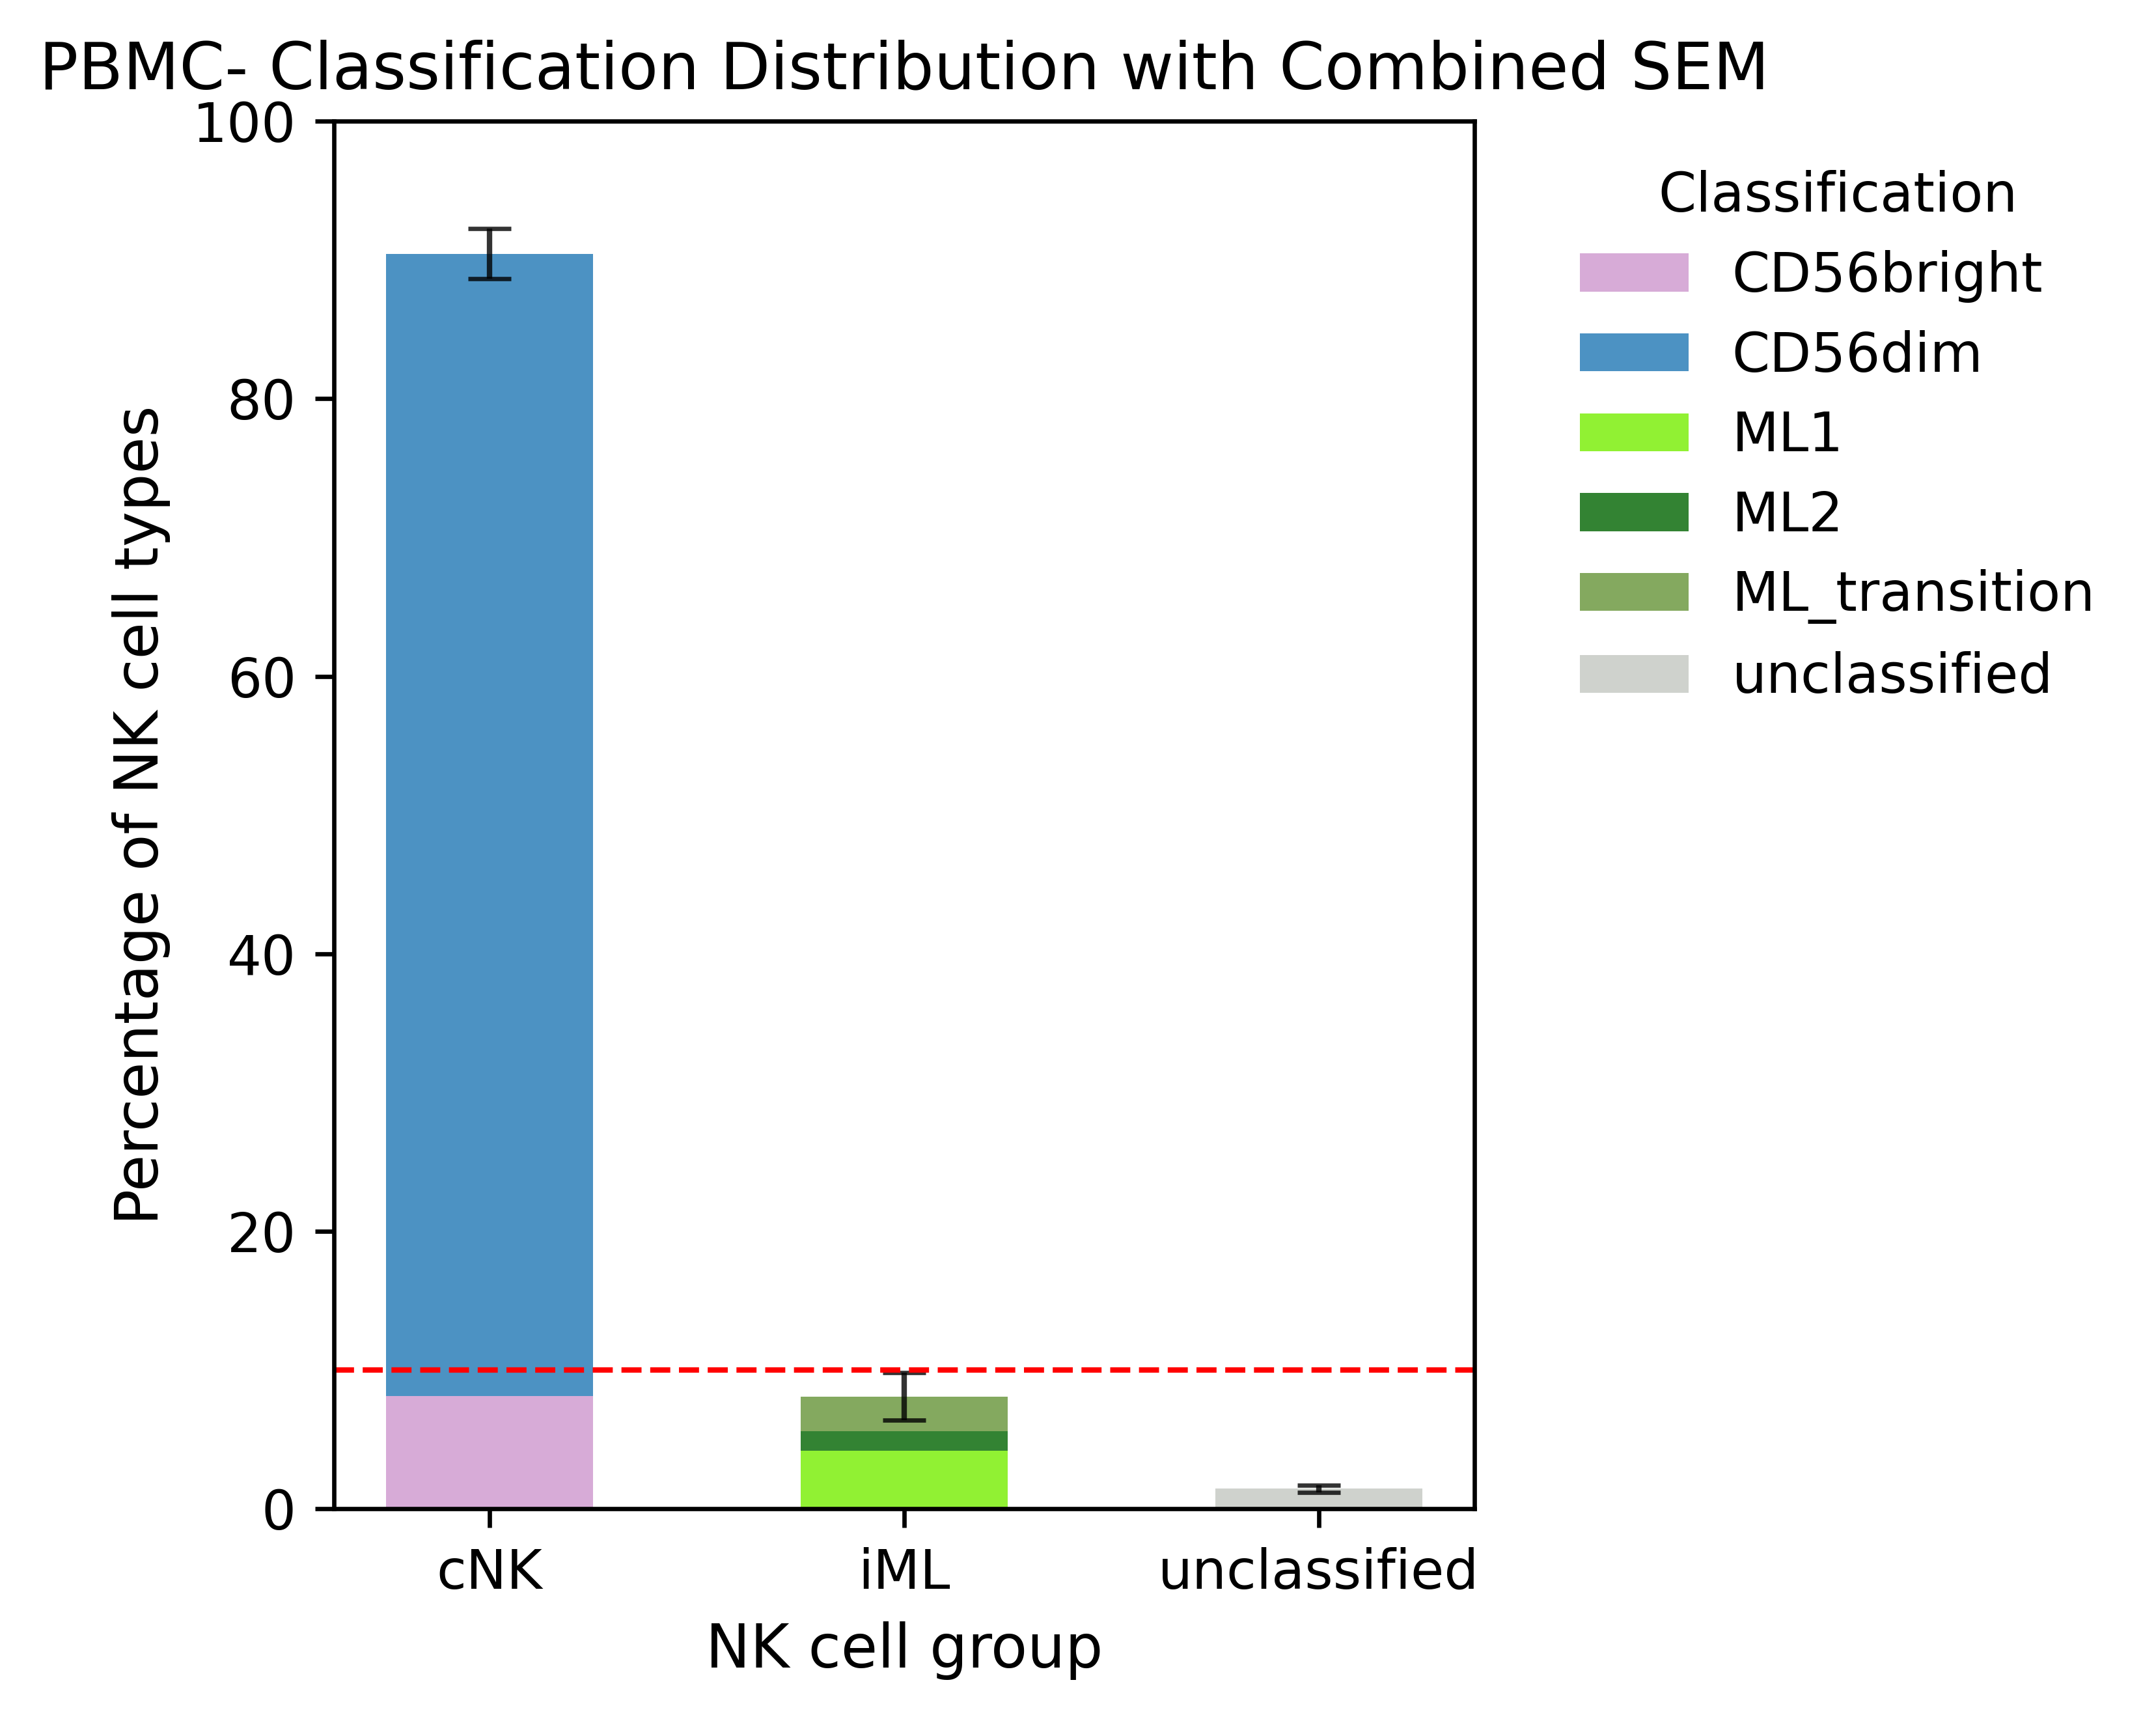

In [85]:
sample_totals = df.groupby('sample').size()
# Count cells in each (sample, group, classification) combination
grouped = df.groupby(['sample', 'group', 'classification']).size()

# Calculate percentage of total for each sample
actual_percentages_list = []
for sample in df['sample'].unique():
    sample_total = sample_totals[sample]
    
    for group in df['group'].unique():
        for classification in df['classification'].unique():
            if (sample, group, classification) in grouped.index:
                pct = (grouped[(sample, group, classification)] / sample_total) * 100
                actual_percentages_list.append({
                    'sample': sample,
                    'group': group,
                    'classification': classification,
                    'percentage': pct
                })

df_pct = pd.DataFrame(actual_percentages_list)

# Pivot to get the right structure
pct_pivot = df_pct.pivot_table(
    index=['sample', 'group'], 
    columns='classification', 
    values='percentage', 
    fill_value=0
)

# Step 2: Calculate mean and SEM by group
mean_percentages = pct_pivot.groupby('group').mean()
# Calculate total percentage per sample by group
pct_pivot['total'] = pct_pivot.sum(axis=1)

# SEM of the total across samples for each group
combined_sem_direct = pct_pivot.groupby('group')['total'].sem()

# Step 4: Create stacked bar plot
fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=600)

classifications = mean_percentages.columns.tolist()
groups = mean_percentages.index.tolist()
colors = ["#CD96CD", '#1f77b4', '#76EE00', '#006400', '#659437' , '#c4c7c1', ]

x = np.arange(len(groups))
width = 0.5
bottom = np.zeros(len(groups))

# Create stacked bars
for i, classification in enumerate(classifications):
    values = mean_percentages[classification].values
    ax.bar(x, values, width, label=classification, bottom=bottom, 
           color=colors[i], alpha=0.8)
    bottom += values

# Add combined error bars at the top of the stacked bars
ax.errorbar(x, bottom, yerr=combined_sem_direct.values, fmt='none', 
            ecolor='black', capsize=4, capthick=0.8, alpha=0.8, linewidth=1)

# Customize plot
ax.set_ylim(0, 100)
ax.set_ylabel('Percentage of NK cell types', fontsize=11)
ax.set_xlabel('NK cell group', fontsize=11)
ax.set_title('PBMC- Classification Distribution with Combined SEM', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left', frameon= False)
ax.axhline(10, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()